<a href="https://colab.research.google.com/github/mafaiziyas/Wearable-AI-Barbell-Activity-Recognition-and-Rep-Counting-Engine/blob/main/scripts/Detecting_Outliers_using_Rolling_IQR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_pickle("/content/drive/MyDrive/Fitness Tracker/Intermediate Data Files (post Data_preprocessing)/processed_data_file.pkl")
df.head()
df.columns

Index(['acc_x (g)', 'acc_y (g)', 'acc_z (g)', 'gyr_x (deg/s)', 'gyr_y (deg/s)',
       'gyr_z (deg/s)', 'participant', 'label', 'category', 'set'],
      dtype='object')


--- Plots for Exercise: BENCH ---


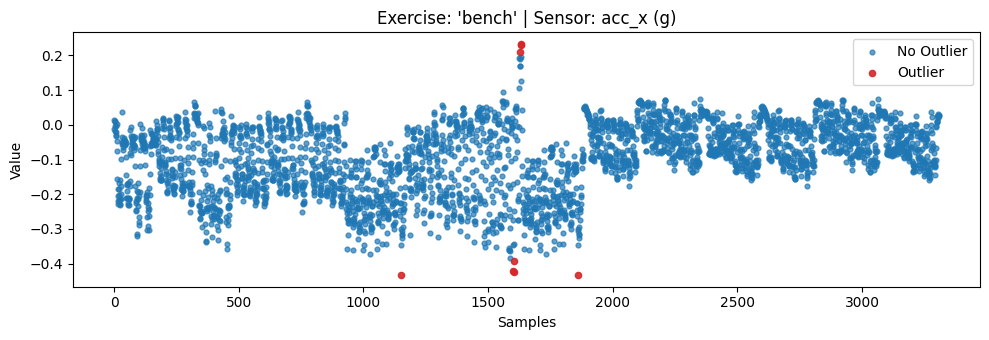

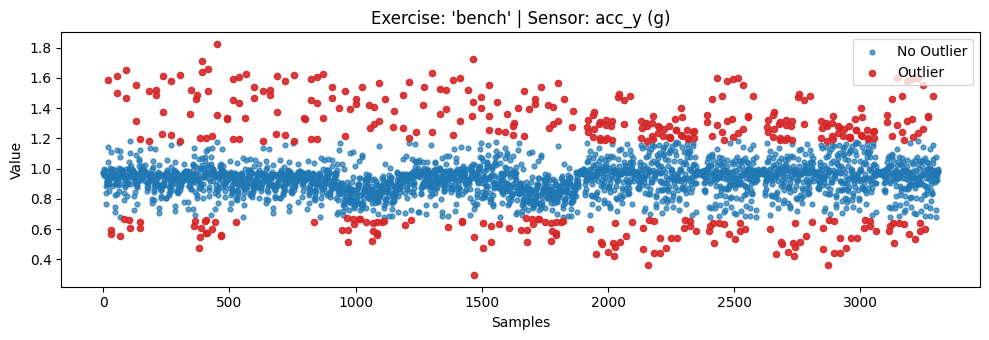

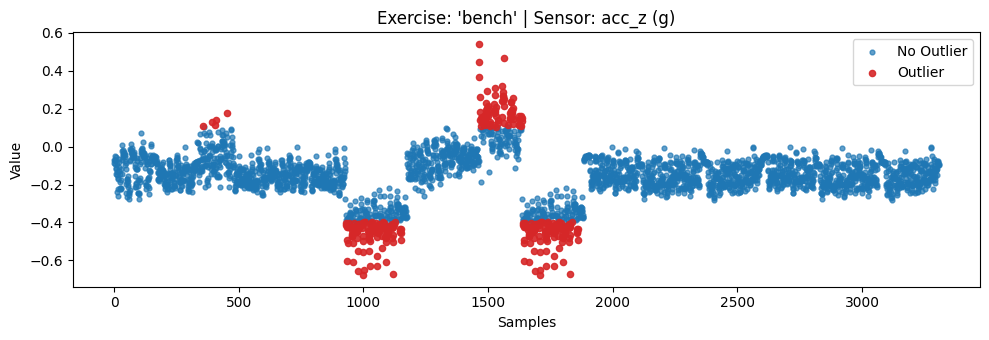

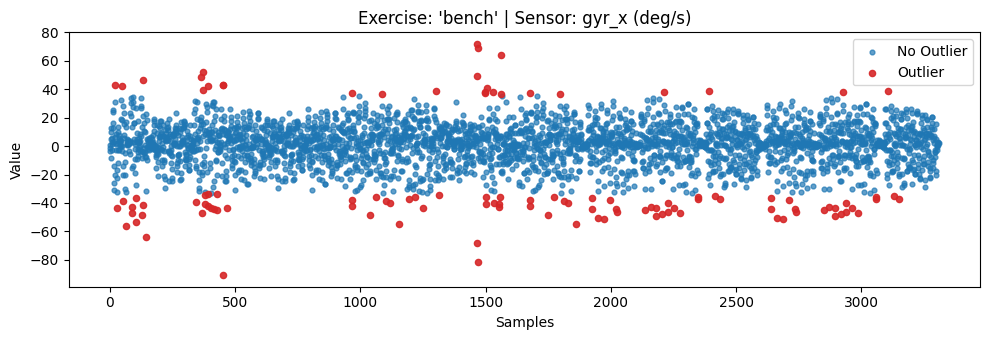

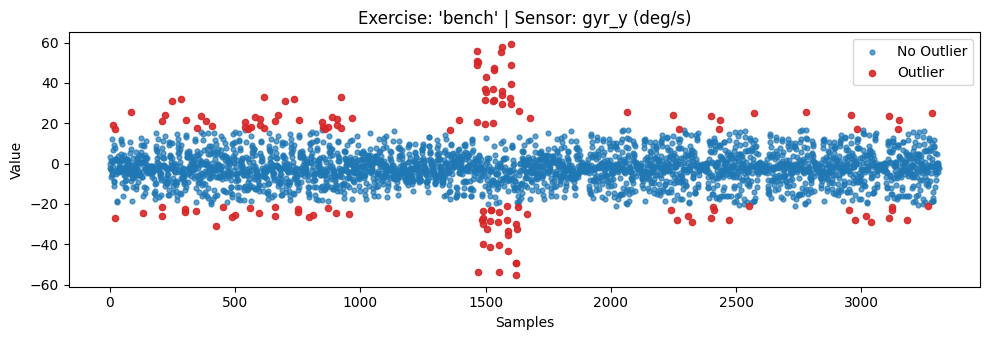

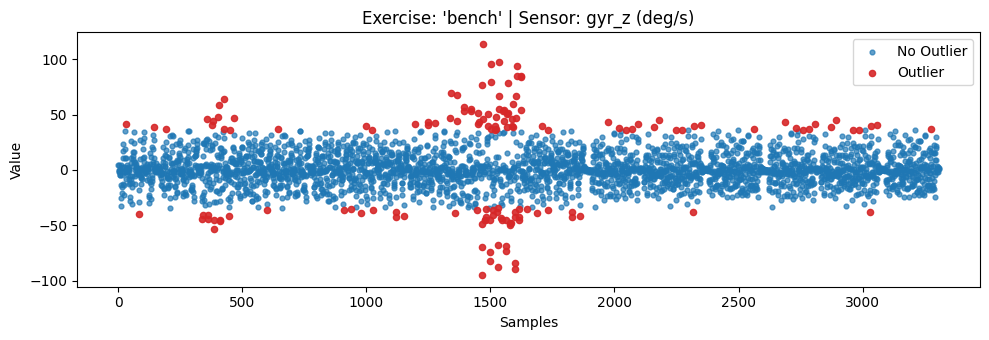


--- Plots for Exercise: OHP ---


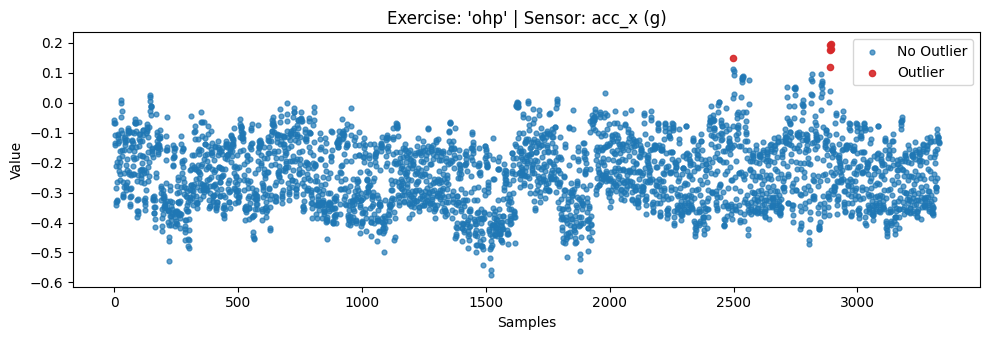

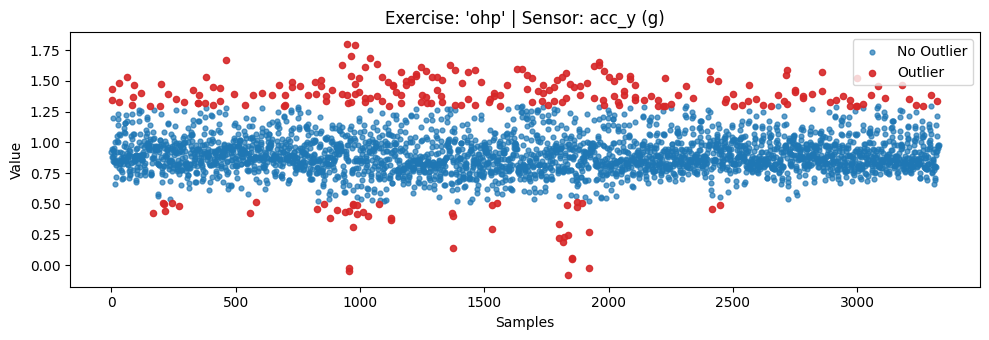

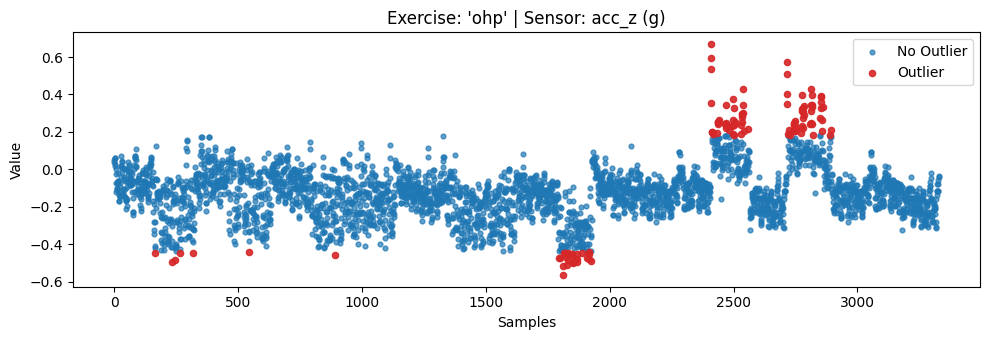

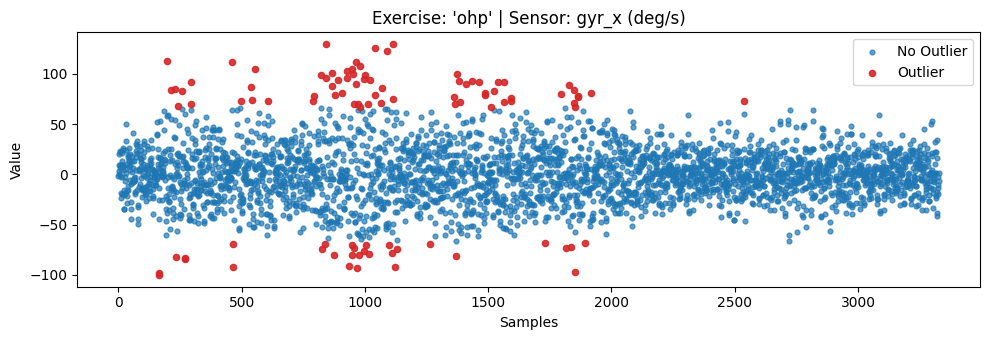

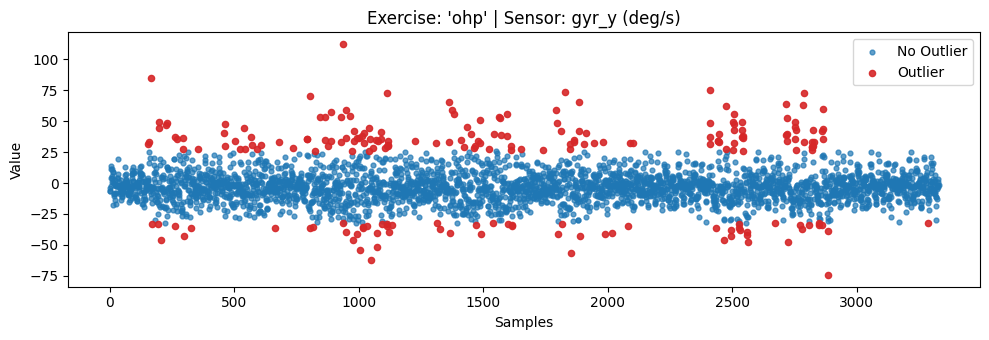

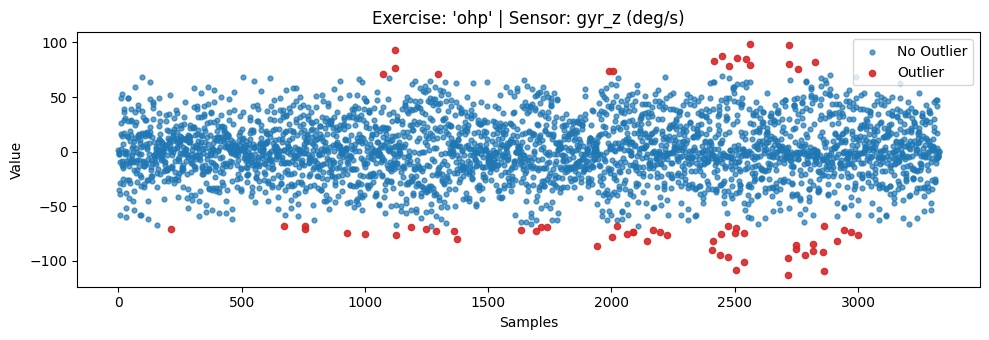


--- Plots for Exercise: SQUAT ---


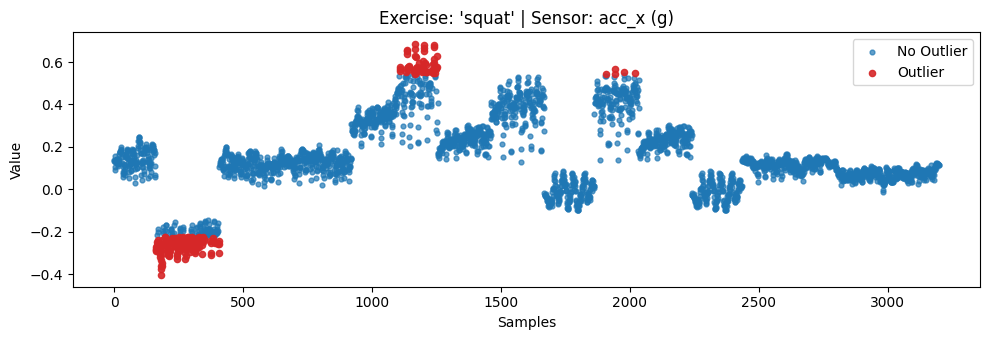

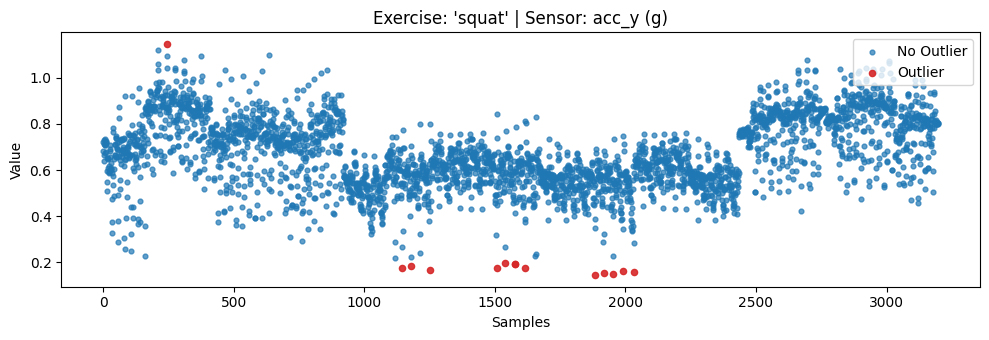

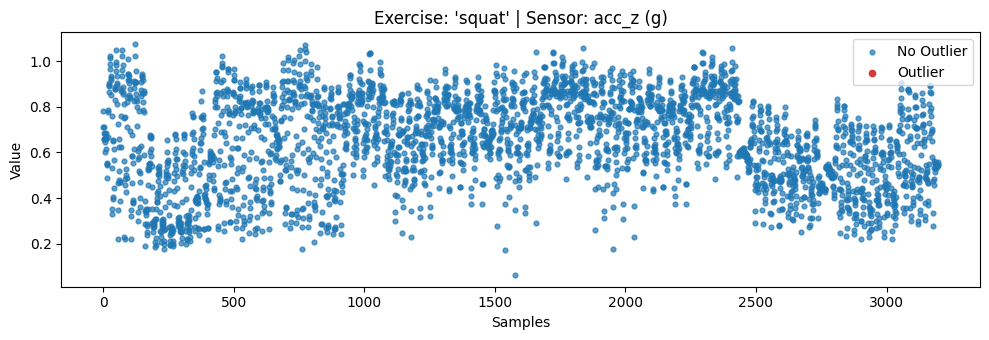

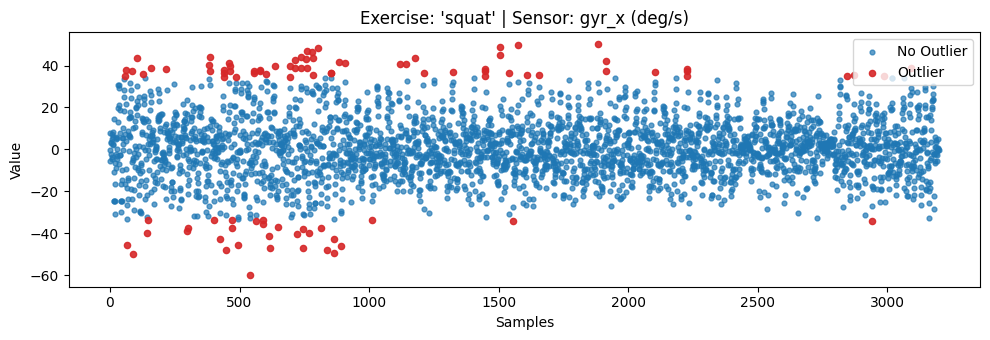

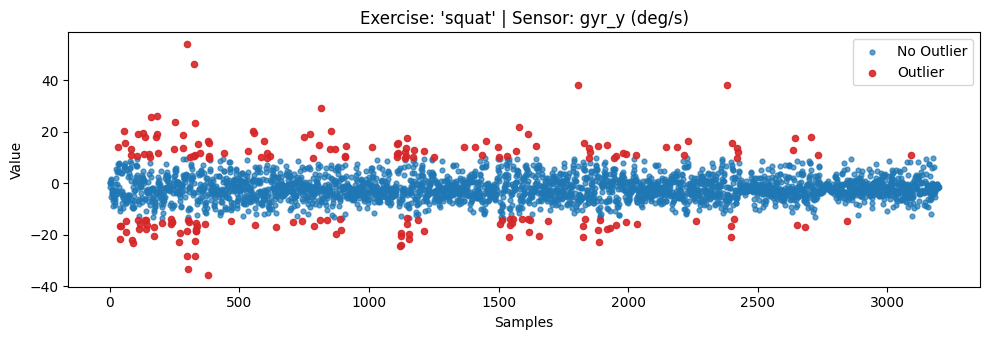

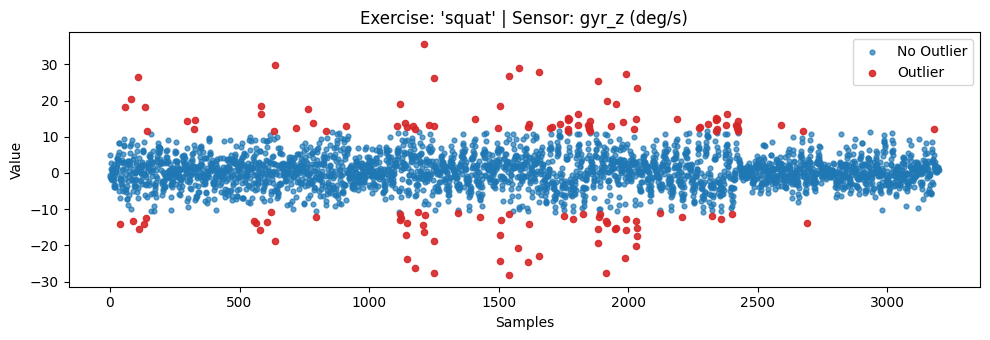


--- Plots for Exercise: DEAD ---


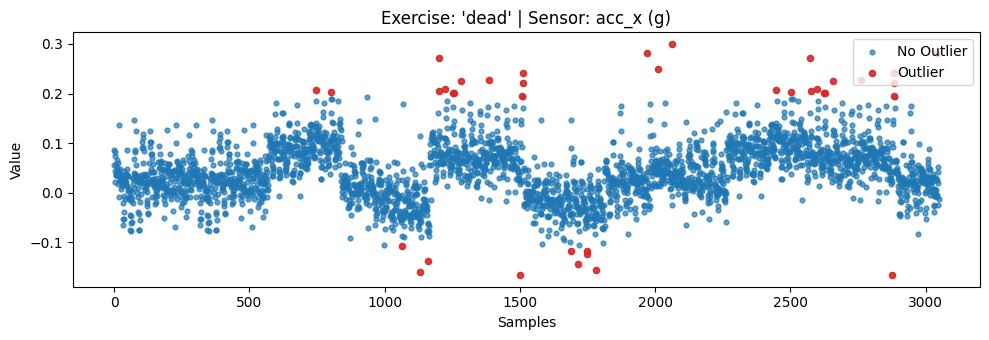

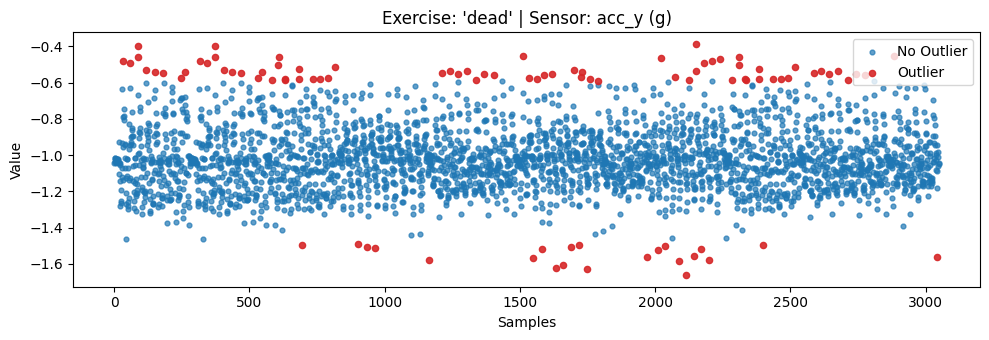

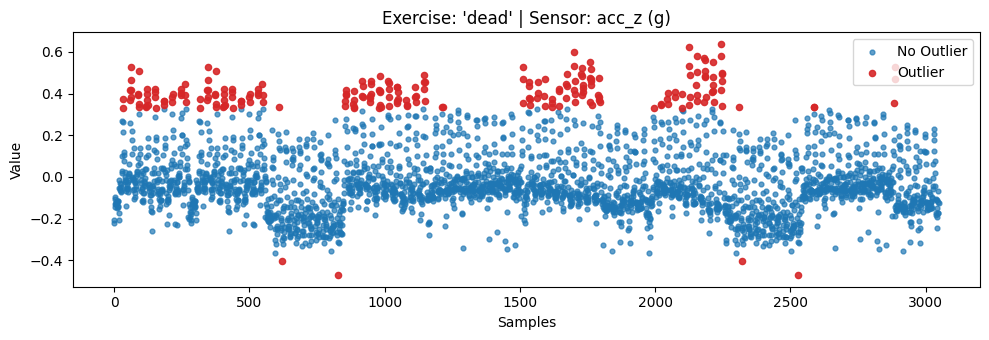

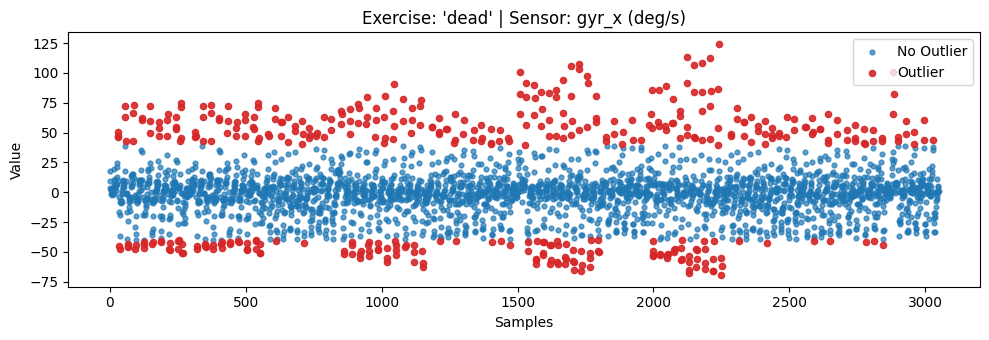

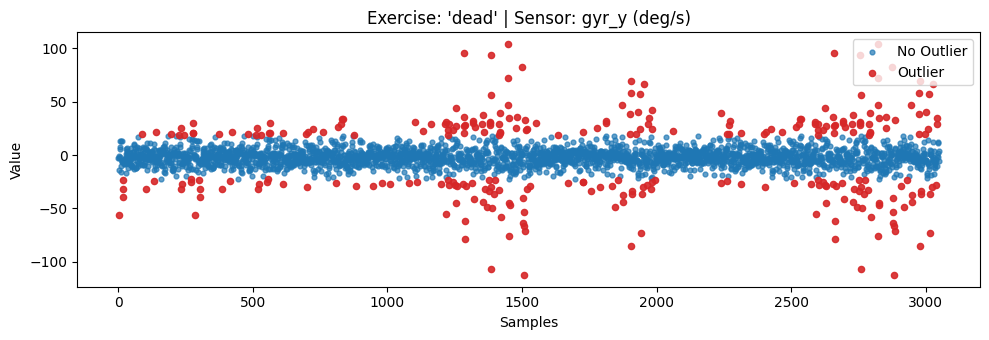

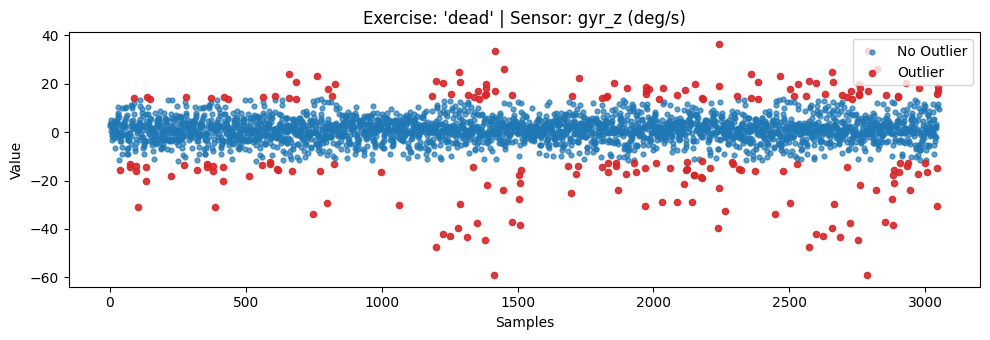


--- Plots for Exercise: ROW ---


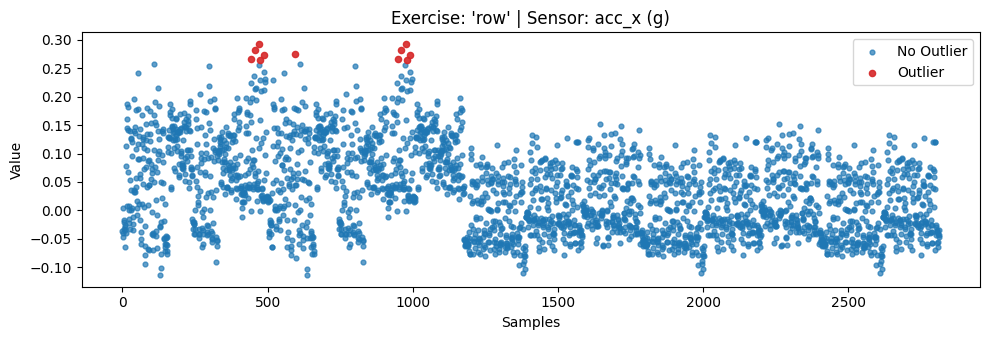

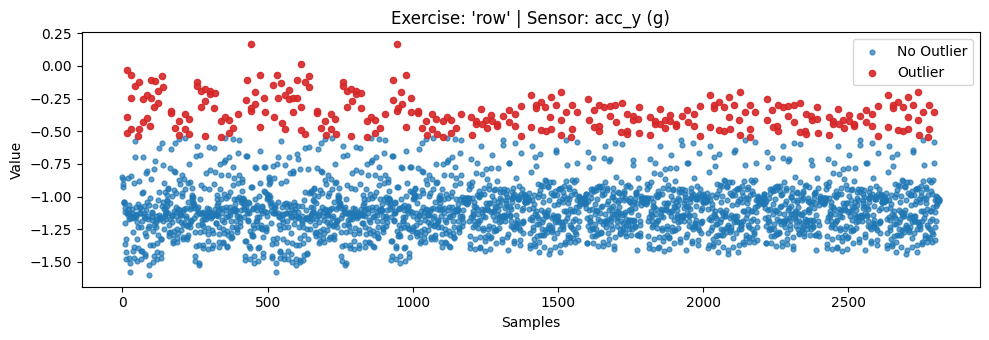

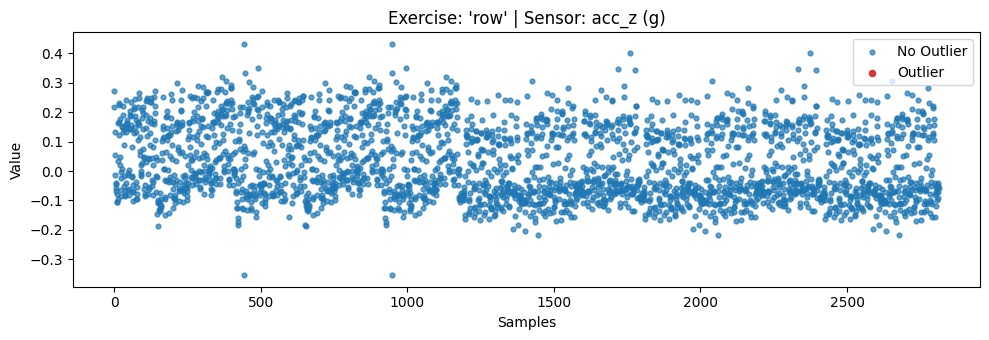

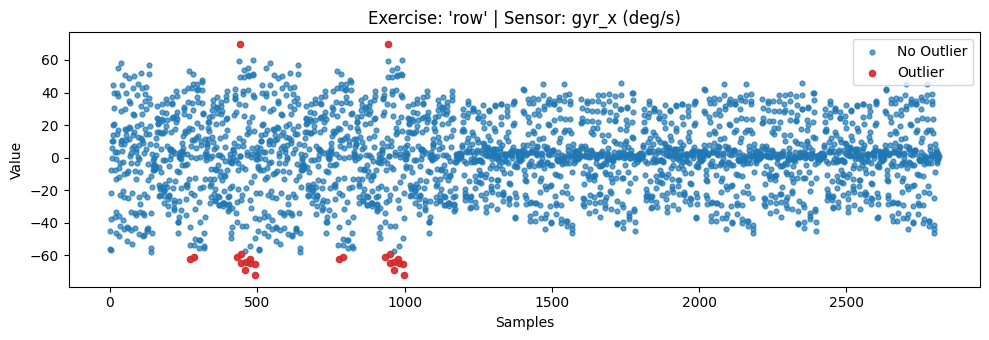

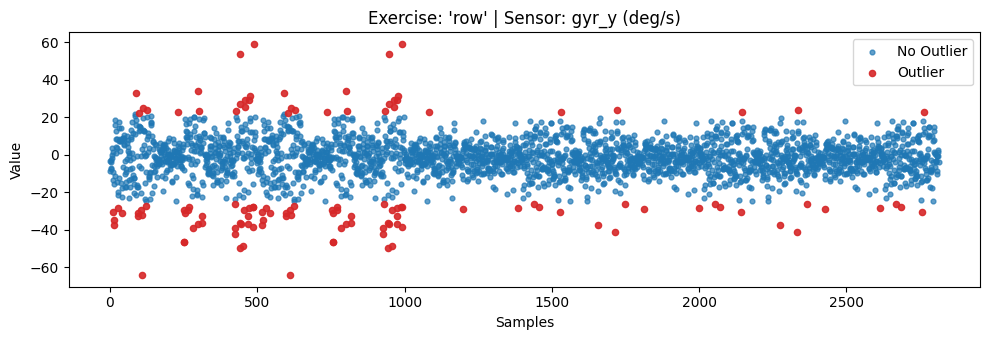

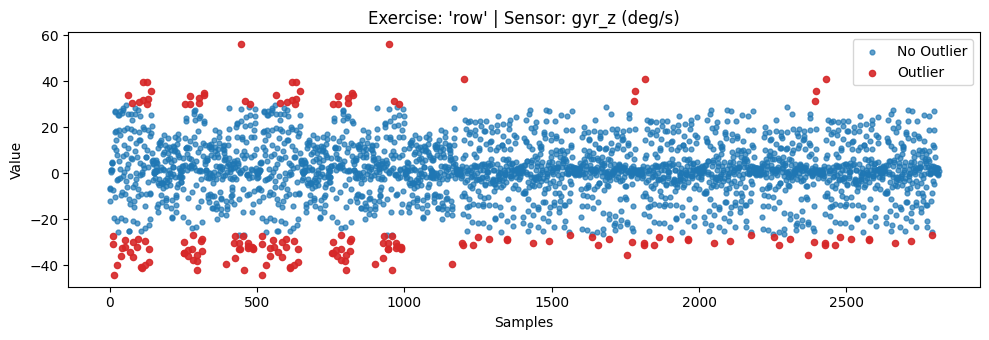

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# IQR Outlier Marker (Class-Segregated)
def mark_outliers_iqr(df, col, k=1.5):
    """Marks outliers per exercise class using IQR without removing them."""
    outlier_col = f"{col}_outlier"
    df[outlier_col] = False

    # Compute bounds per exercise label
    for label, group in df.groupby("label", dropna=True):
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - (k * iqr)
        upper = q3 + (k * iqr)

        mask = (df["label"] == label) & ((df[col] < lower) | (df[col] > upper))
        df.loc[mask, outlier_col] = True

    return df


# Plotting Function for a Single Exercise + Sensor Combination
def plot_exercise_sensor(df, label, col):
    """Plots sensor signal for a specific exercise class with reset sample index."""
    outlier_col = f"{col}_outlier"

    # Filter for the specific exercise and reset sample index for clean sequence
    subset = df[df["label"] == label].reset_index(drop=True)

    if subset.empty:
        return

    plt.figure(figsize=(10, 3.5))

    # Normal data points (Blue)
    normal_data = subset[~subset[outlier_col]]
    plt.scatter(
        normal_data.index,
        normal_data[col],
        c="tab:blue",
        s=12,
        alpha=0.7,
        label="No Outlier",
    )

    # Outlier points (Red)
    outliers = subset[subset[outlier_col]]
    plt.scatter(
        outliers.index,
        outliers[col],
        c="tab:red",
        s=20,
        alpha=0.9,
        label="Outlier",
    )

    plt.title(f"Exercise: '{label}' | Sensor: {col}")
    plt.xlabel("Samples")
    plt.ylabel("Value")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# --- Execution Pipeline ---
sensor_cols = [
    "acc_x (g)",
    "acc_y (g)",
    "acc_z (g)",
    "gyr_x (deg/s)",
    "gyr_y (deg/s)",
    "gyr_z (deg/s)",
]

# Get list of valid exercises (excluding NaN)
exercises = [
    label
    for label in df["label"].unique()
    if pd.notna(label) and label != "rest"
]
# Note: Add 'rest' back to the list above if you wish to inspect rest periods too

# Step 1: Flag outliers across all sensor columns
for col in sensor_cols:
    df = mark_outliers_iqr(df, col, k=1.5)

# Step 2: Render individual graphs (One graph per Exercise x Sensor combination)
for exercise in exercises:
    print(f"\n--- Plots for Exercise: {exercise.upper()} ---")
    for col in sensor_cols:
        plot_exercise_sensor(df, exercise, col)
